# Phase 2 — Preprocessing & Feature Engineering
### UNSW-NB15 — GNN-based NIDS Pipeline

**Input :** 4 raw CSV files → 2,540,047 rows × 49 cols  
**Output:** Scaled, balanced, encoded train / val / test arrays + per-IP node features for GNN

| Step | Task |
|---|---|
| 2.1 | Load raw files |
| 2.2 | Deduplication & null treatment |
| 2.3 | Drop correlated & identifier features |
| 2.4 | Encode multiclass target (`attack_cat`) |
| 2.5 | Stratified 80/20 train / val split + official test set |
| 2.6 | Node-level feature engineering (per-IP aggregations for GNN) |
| 2.7 | Categorical encoding (`proto` freq, `service`/`state` label) |
| 2.8 | Build feature matrices X |
| 2.9 | `RobustScaler` (fit on train only) |
| 2.10 | Binary imbalance — `RandomOverSampler` |
| 2.11 | Multiclass imbalance — `SMOTE` on severe minorities |
| 2.12 | Save all outputs |
| 2.13 | Summary |

## 2.0 — Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, RandomOverSampler

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = r'c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15'
OUT_PRE = os.path.join(BASE, 'outputs', 'preprocessed')
OUT_ENC = os.path.join(BASE, 'outputs', 'encoders')
OUT_EDA = os.path.join(BASE, 'outputs', 'eda')
for d in [OUT_PRE, OUT_ENC]:
    os.makedirs(d, exist_ok=True)

# ── 49-column schema (NUSW-NB15_features.csv order) ──────────────────────────
COLUMNS = [
    'srcip','sport','dstip','dsport','proto','state',
    'dur','sbytes','dbytes','sttl','dttl','sloss','dloss',
    'service','Sload','Dload','Spkts','Dpkts',
    'swin','dwin','stcpb','dtcpb','smeansz','dmeansz',
    'trans_depth','res_bdy_len','Sjit','Djit',
    'Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat',
    'is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd',
    'is_ftp_login','ct_ftp_cmd',
    'ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm',
    'attack_cat','label'
]

# ── Column groups ──────────────────────────────────────────────────────────────
IP_COLS      = ['srcip', 'dstip']        # kept until node-feat step, then excluded from X
TS_COLS      = ['Stime', 'Ltime']        # raw UNIX timestamps — exclude from X
TARGET_COLS  = ['attack_cat', 'label']   # targets, never in X

# Drop one from each high-corr pair (r > 0.95 from Phase 1).
# Keep the member with higher RF importance in each pair.
# Pair → keep   : dwin/swin→swin(keep), Dpkts/dloss→Dpkts, dloss/dbytes→dbytes,
#                  sloss/sbytes→sbytes, ct_src_dport_ltm/ct_dst_ltm→ct_dst_ltm,
#                  ct_srv_dst/ct_srv_src→ct_srv_dst, ct_dst_src_ltm/ct_srv_dst→ct_srv_dst
DROP_CORR    = ['dwin', 'dloss', 'sloss',
                'ct_src_dport_ltm', 'ct_srv_src', 'ct_dst_src_ltm']

# Sparse null cols: protocol-specific flags (0 = not applicable)
NULL_FILL_ZERO = ['ct_flw_http_mthd', 'is_ftp_login']

# Official pre-split test set path
OFFICIAL_TEST_PATH = os.path.join(
    BASE, 'Training and Testing Sets', 'UNSW_NB15_testing-set.csv')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print('Setup complete.')
print(f'  Preprocessed outputs → {OUT_PRE}')
print(f'  Encoder outputs      → {OUT_ENC}')

Setup complete.
  Preprocessed outputs → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\preprocessed
  Encoder outputs      → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\encoders


## 2.1 — Load Raw Files
Reuse the exact load logic from Phase 1 (UTF-8 BOM fix, `attack_cat` normalisation, port coercion).

In [2]:
file_stats = []
dfs = []

for i in range(1, 5):
    path = os.path.join(BASE, f'UNSW-NB15_{i}.csv')
    df_i = pd.read_csv(path, header=None, names=COLUMNS,
                       encoding='latin1', low_memory=False)
    # Fix UTF-8 BOM that appears in file 1's srcip
    df_i['srcip'] = (df_i['srcip'].astype(str)
                     .str.replace('\ufeff', '', regex=False).str.strip())
    # Normalise attack_cat: strip whitespace, merge Backdoor/Backdoors
    df_i['attack_cat'] = (df_i['attack_cat'].astype(str).str.strip()
                          .replace({'nan': 'Normal', '': 'Normal', 'Backdoors': 'Backdoor'})
                          .fillna('Normal'))
    df_i['label'] = pd.to_numeric(df_i['label'], errors='coerce').fillna(0).astype(int)
    # Coerce port columns (may contain hex strings like '0x0016')
    for col in ['sport', 'dsport']:
        df_i[col] = pd.to_numeric(df_i[col], errors='coerce').fillna(0).astype(np.int32)

    n_total  = len(df_i)
    n_normal = (df_i['label'] == 0).sum()
    n_attack = (df_i['label'] == 1).sum()
    file_stats.append({'file': f'UNSW-NB15_{i}.csv',
                       'total': n_total, 'normal': n_normal, 'attack': n_attack})
    print(f'File {i}: {n_total:>9,} rows  |  normal={n_normal:>9,}  |  attack={n_attack:>7,}')
    dfs.append(df_i)

df = pd.concat(dfs, ignore_index=True)
df['attack_cat'] = df['attack_cat'].fillna('Normal')

attack_cats = sorted(c for c in df['attack_cat'].unique() if c != 'Normal')
print(f'\nCombined : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Attack categories ({len(attack_cats)}): {attack_cats}')

File 1:   700,001 rows  |  normal=  677,786  |  attack= 22,215
File 2:   700,001 rows  |  normal=  647,252  |  attack= 52,749
File 3:   700,001 rows  |  normal=  542,576  |  attack=157,425
File 4:   440,044 rows  |  normal=  351,150  |  attack= 88,894

Combined : 2,540,047 rows × 49 cols
Attack categories (9): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


## 2.2 — Cleaning: Null Treatment & Deduplication

| Column | Null % | Treatment | Rationale |
|---|---|---|---|
| `ct_flw_http_mthd` | 53.1% | Fill 0 | Non-HTTP flows have no method |
| `is_ftp_login` | 56.3% | Fill 0 | Non-FTP flows are not logins |

In [3]:
# ── 2.2.1  Fill sparse protocol-specific columns ──────────────────────────────
before_nulls = {c: int(df[c].isnull().sum()) for c in NULL_FILL_ZERO}
for c in NULL_FILL_ZERO:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

print('Null treatment (protocol-specific flags → 0):')
for c in NULL_FILL_ZERO:
    print(f'  {c:30s}  before={before_nulls[c]:>9,}  after={int(df[c].isnull().sum())}')

# ── 2.2.2  Coerce remaining numeric columns ───────────────────────────────────
# Handles any stray non-numeric strings in numeric-expected columns
skip_coerce = set(IP_COLS + ['proto', 'service', 'state', 'attack_cat'])
for c in df.columns:
    if c not in skip_coerce:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# ── 2.2.3  Drop duplicate rows ────────────────────────────────────────────────
n_before  = len(df)
df        = df.drop_duplicates().reset_index(drop=True)
n_after   = len(df)
n_dropped = n_before - n_after

print(f'\nDuplicate rows dropped : {n_dropped:>9,}  ({n_dropped / n_before * 100:.2f}%)')
print(f'Rows remaining         : {n_after:>9,}')

# ── 2.2.4  Final null check ───────────────────────────────────────────────────
total_nulls = df.select_dtypes(include=np.number).isnull().sum().sum()
print(f'Total numeric nulls remaining : {total_nulls}')
print(f'Attack category distribution  :')
print(df['attack_cat'].value_counts().to_string())

Null treatment (protocol-specific flags → 0):
  ct_flw_http_mthd                before=1,348,145  after=0
  is_ftp_login                    before=1,429,879  after=0

Duplicate rows dropped :   480,639  (18.92%)
Rows remaining         : 2,059,408
Total numeric nulls remaining : 0
Attack category distribution  :
attack_cat
Normal            1959765
Exploits            27599
Generic             25378
Fuzzers             21795
Reconnaissance      13357
DoS                  5665
Analysis             2184
Backdoor             1983
Shellcode            1511
Worms                 171


## 2.3 — Feature Selection: Drop Correlated & Identifier Features

Drop one feature from each of the 8 high-correlation pairs (r > 0.95) found in Phase 1 EDA.  
**Rule:** keep the member with higher RF importance rank; drop the other.

| Dropped | Correlated Pair | r | Keep (reason) |
|---|---|---|---|
| `dwin` | dwin ↔ swin | 0.997 | `swin` |
| `dloss` | Dpkts ↔ dloss ↔ dbytes | 0.991 | `dbytes` (RF rank 4) |
| `sloss` | sloss ↔ sbytes | 0.963 | `sbytes` (RF rank 12) |
| `ct_src_dport_ltm` | ct_src_dport_ltm ↔ ct_dst_ltm | 0.960 | `ct_dst_ltm` |
| `ct_srv_src` | ct_srv_dst ↔ ct_srv_src | 0.957 | `ct_srv_dst` |
| `ct_dst_src_ltm` | ct_dst_src_ltm ↔ ct_srv_dst | 0.951 | `ct_srv_dst` |

In [4]:
print(f'Columns before feature selection : {len(df.columns)}')
print(f'Dropping high-corr columns       : {DROP_CORR}')

df = df.drop(columns=DROP_CORR)

# Define final feature column list
# IP_COLS and TS_COLS are still in df for now (needed for node feature engineering)
# They will be excluded from the model feature matrix X
FEATURE_COLS = [c for c in df.columns
                if c not in TARGET_COLS + IP_COLS + TS_COLS]

print(f'\nFinal feature set ({len(FEATURE_COLS)} features):')
for i, c in enumerate(FEATURE_COLS):
    print(f'  {i+1:2d}. {c}')

Columns before feature selection : 49
Dropping high-corr columns       : ['dwin', 'dloss', 'sloss', 'ct_src_dport_ltm', 'ct_srv_src', 'ct_dst_src_ltm']

Final feature set (37 features):
   1. sport
   2. dsport
   3. proto
   4. state
   5. dur
   6. sbytes
   7. dbytes
   8. sttl
   9. dttl
  10. service
  11. Sload
  12. Dload
  13. Spkts
  14. Dpkts
  15. swin
  16. stcpb
  17. dtcpb
  18. smeansz
  19. dmeansz
  20. trans_depth
  21. res_bdy_len
  22. Sjit
  23. Djit
  24. Sintpkt
  25. Dintpkt
  26. tcprtt
  27. synack
  28. ackdat
  29. is_sm_ips_ports
  30. ct_state_ttl
  31. ct_flw_http_mthd
  32. is_ftp_login
  33. ct_ftp_cmd
  34. ct_srv_dst
  35. ct_dst_ltm
  36. ct_src_ltm
  37. ct_dst_sport_ltm


## 2.4 — Encode Multiclass Target: `attack_cat`

`LabelEncoder` fitted on the full dataset (all 10 classes are present; no leakage since this is the **target**, not a feature).  
Encoder saved to `outputs/encoders/` for use in evaluation phases.

In [5]:
le_attack_cat = LabelEncoder()
df['attack_cat_enc'] = le_attack_cat.fit_transform(df['attack_cat'])

print('attack_cat → integer encoding:')
for i, cls in enumerate(le_attack_cat.classes_):
    cnt = (df['attack_cat_enc'] == i).sum()
    print(f'  {i:2d}  {cls:20s}  {cnt:>10,}')

# Save
with open(os.path.join(OUT_ENC, 'le_attack_cat.pkl'), 'wb') as f:
    pickle.dump(le_attack_cat, f)
print('\nSaved → le_attack_cat.pkl')

attack_cat → integer encoding:
   0  Analysis                   2,184
   1  Backdoor                   1,983
   2  DoS                        5,665
   3  Exploits                  27,599
   4  Fuzzers                   21,795
   5  Generic                   25,378
   6  Normal                 1,959,765
   7  Reconnaissance            13,357
   8  Shellcode                  1,511
   9  Worms                        171

Saved → le_attack_cat.pkl


## 2.5 — Train / Val / Test Split

- **Train + Val**: All 4 raw files (post-dedup). Stratified 80 / 20 on binary `label`.  
- **Test**: Official `UNSW_NB15_testing-set.csv` (82,332 rows) — **never used for fitting**.

In [6]:
y_binary = df['label'].values
indices  = np.arange(len(df))

train_idx, val_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_binary
)

df_train = df.iloc[train_idx].copy().reset_index(drop=True)
df_val   = df.iloc[val_idx].copy().reset_index(drop=True)

print(f'Train rows  : {len(df_train):>9,}  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   rows  : {len(df_val):>9,}  ({len(df_val)/len(df)*100:.1f}%)')

for split_name, d_ in [('Train', df_train), ('Val', df_val)]:
    vc = d_['label'].value_counts()
    print(f'\n{split_name} label distribution:')
    print(f'  Normal: {vc.get(0,0):>9,}  ({vc.get(0,0)/len(d_)*100:.2f}%)')
    print(f'  Attack: {vc.get(1,0):>9,}  ({vc.get(1,0)/len(d_)*100:.2f}%)')

Train rows  : 1,647,526  (80.0%)
Val   rows  :   411,882  (20.0%)

Train label distribution:
  Normal: 1,567,812  (95.16%)
  Attack:    79,714  (4.84%)

Val label distribution:
  Normal:   391,953  (95.16%)
  Attack:    19,929  (4.84%)


In [7]:
# ── Load and inspect official test set ───────────────────────────────────────
df_test_raw = pd.read_csv(OFFICIAL_TEST_PATH, low_memory=False)
print(f'Official test set: {df_test_raw.shape}')
print(f'Columns ({len(df_test_raw.columns)}): {df_test_raw.columns.tolist()}')

Official test set: (82332, 45)
Columns (45): ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [8]:
df_test = df_test_raw.copy()

# ── Column name normalisation: official set uses lowercase / different aliases ─
# Map known alias → our schema column name
TEST_ALIASES = {
    'smean'            : 'smeansz',
    'dmean'            : 'dmeansz',
    'sinpkt'           : 'Sintpkt',
    'dinpkt'           : 'Dintpkt',
    'sjit'             : 'Sjit',
    'djit'             : 'Djit',
    'sload'            : 'Sload',
    'dload'            : 'Dload',
    'spkts'            : 'Spkts',
    'dpkts'            : 'Dpkts',
    'response_body_len': 'res_bdy_len',
}
rename_map = {k: v for k, v in TEST_ALIASES.items() if k in df_test.columns}
df_test = df_test.rename(columns=rename_map)

# Case-insensitive fallback for any remaining mismatches
lower_feat = {f.lower(): f for f in FEATURE_COLS}
extra = {c: lower_feat[c.lower()]
         for c in df_test.columns
         if c.lower() in lower_feat and lower_feat[c.lower()] not in df_test.columns}
df_test = df_test.rename(columns=extra)

# ── Normalise attack_cat ──────────────────────────────────────────────────────
if 'attack_cat' in df_test.columns:
    df_test['attack_cat'] = (df_test['attack_cat'].astype(str).str.strip()
                              .replace({'nan': 'Normal', '': 'Normal', 'Backdoors': 'Backdoor'})
                              .fillna('Normal'))
    # Map unseen categories to 'Normal' for safety
    known_cats = set(le_attack_cat.classes_)
    df_test['attack_cat'] = df_test['attack_cat'].apply(
        lambda x: x if x in known_cats else 'Normal')
    df_test['attack_cat_enc'] = le_attack_cat.transform(df_test['attack_cat'])

# ── Coerce label ──────────────────────────────────────────────────────────────
df_test['label'] = pd.to_numeric(df_test['label'], errors='coerce').fillna(0).astype(int)

# ── Drop high-corr columns (if present) ──────────────────────────────────────
drop_test = [c for c in DROP_CORR if c in df_test.columns]
df_test   = df_test.drop(columns=drop_test)

# ── Fill nulls ────────────────────────────────────────────────────────────────
for c in NULL_FILL_ZERO:
    if c in df_test.columns:
        df_test[c] = pd.to_numeric(df_test[c], errors='coerce').fillna(0)

# ── Report alignment ─────────────────────────────────────────────────────────
matched = [c for c in FEATURE_COLS if c in df_test.columns]
missing = [c for c in FEATURE_COLS if c not in df_test.columns]
print(f'Test columns matched  : {len(matched)} / {len(FEATURE_COLS)}')
if missing:
    print(f'Missing (will fill 0) : {missing}')
test_vc = df_test['label'].value_counts()
print(f'\nTest label distribution:')
print(f'  Normal: {test_vc.get(0,0):>9,}  ({test_vc.get(0,0)/len(df_test)*100:.2f}%)')
print(f'  Attack: {test_vc.get(1,0):>9,}  ({test_vc.get(1,0)/len(df_test)*100:.2f}%)')

Test columns matched  : 35 / 37
Missing (will fill 0) : ['sport', 'dsport']

Test label distribution:
  Normal:    37,000  (44.94%)
  Attack:    45,332  (55.06%)


## 2.6 — Node-Level Feature Engineering (for GNN Phase 3)

Computed from **training rows only** to prevent label leakage.  
Each unique IP address becomes a **node** in the GNN graph; these aggregated features become its feature vector.

| Feature | Description | Computed from |
|---|---|---|
| `out_degree` | # flows sourced from IP | train flows |
| `in_degree` | # flows destined to IP | train flows |
| `total_degree` | out + in | derived |
| `mean_sbytes` | Mean source bytes | train flows |
| `mean_dbytes` | Mean destination bytes | train flows |
| `total_bytes` | mean_sbytes + mean_dbytes | derived |
| `mean_dur` | Mean flow duration | train flows |
| `unique_dsport` | Unique dst ports used | train flows |
| `unique_proto` | Unique protocols used | train flows |
| `src_attack_ratio` | Fraction of outgoing flows that are attacks | train **labels** only |
| `dst_attack_ratio` | Fraction of incoming flows that are attacks | train **labels** only |

> `src_attack_ratio` / `dst_attack_ratio` use training labels → **NEVER compute from val/test**.

In [9]:
# Note: proto is still a string here (encoding happens in §2.7), so nunique() is correct
print('Computing per-IP node features from training rows...')

# ── Source-IP aggregations ────────────────────────────────────────────────────
src_agg = (df_train
           .groupby('srcip', sort=False)
           .agg(
               out_degree      = ('srcip',  'count'),
               mean_sbytes     = ('sbytes', 'mean'),
               mean_dur        = ('dur',    'mean'),
               unique_dsport   = ('dsport', 'nunique'),
               unique_proto    = ('proto',  'nunique'),   # string nunique — correct
               src_attack_ratio= ('label',  'mean'),      # train labels only
           )
           .rename_axis('ip')
           .reset_index())

# ── Destination-IP aggregations ───────────────────────────────────────────────
dst_agg = (df_train
           .groupby('dstip', sort=False)
           .agg(
               in_degree       = ('dstip',  'count'),
               mean_dbytes     = ('dbytes', 'mean'),
               dst_attack_ratio= ('label',  'mean'),      # train labels only
           )
           .rename_axis('ip')
           .reset_index())

# ── Merge into a single node-feature table ────────────────────────────────────
node_feat_df = (pd.merge(src_agg, dst_agg, on='ip', how='outer')
                .fillna(0))
node_feat_df['total_degree'] = node_feat_df['out_degree']  + node_feat_df['in_degree']
node_feat_df['total_bytes']  = node_feat_df['mean_sbytes'] + node_feat_df['mean_dbytes']

NODE_FEAT_COLS = [c for c in node_feat_df.columns if c != 'ip']
print(f'\nNode feature matrix : {node_feat_df.shape}  ({len(NODE_FEAT_COLS)} features per node)')
print(f'Unique IPs (nodes)  : {len(node_feat_df):,}')
print(f'Node feature cols   : {NODE_FEAT_COLS}')
print(f'\nSample node features:')
print(node_feat_df.head(3).to_string())

Computing per-IP node features from training rows...

Node feature matrix : (50, 12)  (11 features per node)
Unique IPs (nodes)  : 50
Node feature cols   : ['out_degree', 'mean_sbytes', 'mean_dur', 'unique_dsport', 'unique_proto', 'src_attack_ratio', 'in_degree', 'mean_dbytes', 'dst_attack_ratio', 'total_degree', 'total_bytes']

Sample node features:
              ip  out_degree  mean_sbytes   mean_dur  unique_dsport  unique_proto  src_attack_ratio  in_degree  mean_dbytes  dst_attack_ratio  total_degree  total_bytes
0    10.40.170.2      1118.0    48.386404   2.468320            1.0           1.0               0.0     1118.0          0.0               0.0        2236.0    48.386404
1    10.40.182.1      2113.0   242.894463  39.917282            2.0           3.0               0.0        0.0          0.0               0.0        2113.0   242.894463
2  10.40.182.255         0.0     0.000000   0.000000            0.0           0.0               0.0       91.0          0.0               0.

In [10]:
# Save node features and IP→index mapping for Phase 3 Graph Construction
node_feat_df.to_csv(os.path.join(OUT_PRE, 'node_features.csv'), index=False)

ip_to_node = {str(ip): int(idx) for idx, ip in enumerate(node_feat_df['ip'])}
with open(os.path.join(OUT_PRE, 'ip_to_node.json'), 'w') as f:
    json.dump(ip_to_node, f)

# Save node feature metadata
node_meta = {
    'n_nodes'        : len(node_feat_df),
    'node_feat_dim'  : len(NODE_FEAT_COLS),
    'node_feat_cols' : NODE_FEAT_COLS,
    'computed_from'  : 'training rows only (anti-leakage)',
}
with open(os.path.join(OUT_PRE, 'node_features_meta.json'), 'w') as f:
    json.dump(node_meta, f, indent=2)

print(f'Saved → node_features.csv      ({len(node_feat_df):,} nodes × {len(NODE_FEAT_COLS)} features)')
print(f'Saved → ip_to_node.json        ({len(ip_to_node):,} IP entries)')
print(f'Saved → node_features_meta.json')

Saved → node_features.csv      (50 nodes × 11 features)
Saved → ip_to_node.json        (50 IP entries)
Saved → node_features_meta.json


## 2.7 — Categorical Encoding

| Feature | Method | Cardinality | Reason |
|---|---|---|---|
| `proto` | **Frequency encoding** (train-only fit) | 135 | Too many for one-hot; preserves protocol prevalence |
| `service` | **Label encoding** | 13 | Low cardinality; fixed domain |
| `state` | **Label encoding** | 16 | Low cardinality; fixed domain |

> `proto` frequency map is fitted on **training data only** (no leakage).  
> Unseen protocols in val/test get frequency = 0 (very rare protocol → treat as noise).

In [11]:
# ── proto: frequency encoding — fit on TRAIN only ────────────────────────────
proto_freq_map = df_train['proto'].value_counts(normalize=True).to_dict()

def apply_proto_freq(series, freq_map):
    return series.astype(str).map(freq_map).fillna(0.0).astype(np.float32)

df_train['proto'] = apply_proto_freq(df_train['proto'], proto_freq_map)
df_val['proto']   = apply_proto_freq(df_val['proto'],   proto_freq_map)
if 'proto' in df_test.columns:
    df_test['proto'] = apply_proto_freq(df_test['proto'], proto_freq_map)

top5_proto = sorted(proto_freq_map.items(), key=lambda x: -x[1])[:5]
print(f'proto freq-encoded | top-5: {top5_proto}')

# ── service & state: label encoding — fit on union of all splits ──────────────
# Fitting on union ensures no Unseen-Label error at transform time
for col, le_name in [('service', 'le_service'), ('state', 'le_state')]:
    le = LabelEncoder()
    all_vals = pd.concat([
        df_train[col], df_val[col],
        df_test[col] if col in df_test.columns else pd.Series([], dtype=str)
    ]).fillna('-').astype(str)
    le.fit(all_vals)

    df_train[col] = le.transform(df_train[col].fillna('-').astype(str))
    df_val[col]   = le.transform(df_val[col].fillna('-').astype(str))
    if col in df_test.columns:
        df_test[col] = le.transform(df_test[col].fillna('-').astype(str))

    with open(os.path.join(OUT_ENC, f'{le_name}.pkl'), 'wb') as fh:
        pickle.dump(le, fh)
    print(f'{col} label-encoded  | {len(le.classes_)} classes | saved {le_name}.pkl')

# Save proto freq map
with open(os.path.join(OUT_ENC, 'proto_freq_map.pkl'), 'wb') as fh:
    pickle.dump(proto_freq_map, fh)
print('proto_freq_map.pkl saved')

proto freq-encoded | top-5: [('tcp', 0.7036435236833896), ('udp', 0.2854127946994463), ('arp', 0.0032788556902895614), ('unas', 0.0022840307224286597), ('ospf', 0.0019259180128265046)]
service label-encoded  | 13 classes | saved le_service.pkl
state label-encoded  | 16 classes | saved le_state.pkl
proto_freq_map.pkl saved


## 2.8 — Build Feature Matrices X

Extract `X` (features), `y_binary` (0/1), and `y_multiclass` (0–9) from each split.  
IP addresses and raw timestamps are excluded here.

In [12]:
# Re-derive FEATURE_COLS_FINAL after all transformations on df_train
FEATURE_COLS_FINAL = [c for c in FEATURE_COLS if c in df_train.columns]
print(f'Final feature columns ({len(FEATURE_COLS_FINAL)}): {FEATURE_COLS_FINAL}')

def build_XY(df_split, feature_cols):
    """Return (X float32, y_binary int32, y_multiclass int32) from a split df."""
    # Fill any missing feature columns with 0 (handles test-set column gaps)
    for c in feature_cols:
        if c not in df_split.columns:
            df_split = df_split.copy()
            df_split[c] = 0.0
    X      = df_split[feature_cols].values.astype(np.float32)
    y_bin  = df_split['label'].values.astype(np.int32)
    y_mult = df_split['attack_cat_enc'].values.astype(np.int32) \
             if 'attack_cat_enc' in df_split.columns \
             else np.zeros(len(df_split), dtype=np.int32)
    return X, y_bin, y_mult

X_train_raw,  y_train_bin,  y_train_mult  = build_XY(df_train, FEATURE_COLS_FINAL)
X_val,        y_val_bin,    y_val_mult    = build_XY(df_val,   FEATURE_COLS_FINAL)
X_test,       y_test_bin,   y_test_mult   = build_XY(df_test,  FEATURE_COLS_FINAL)

print(f'\nX_train_raw : {X_train_raw.shape}  dtype={X_train_raw.dtype}')
print(f'X_val       : {X_val.shape}')
print(f'X_test      : {X_test.shape}')
print(f'\ny_binary   (train unique): {sorted(set(y_train_bin))}')
print(f'y_multiclass(train unique): {sorted(set(y_train_mult))}')

Final feature columns (37): ['sport', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_dst_sport_ltm']

X_train_raw : (1647526, 37)  dtype=float32
X_val       : (411882, 37)
X_test      : (82332, 37)

y_binary   (train unique): [np.int32(0), np.int32(1)]
y_multiclass(train unique): [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]


## 2.9 — Feature Scaling: `RobustScaler`

`RobustScaler` centres on median and scales by IQR — resistant to the extreme outliers  
in network traffic features (e.g., `sbytes`, `Sload`, `Dload`).  

> **Strict anti-leakage:** fitted on training data **only**, then used to transform val and test.

In [13]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'RobustScaler fitted on {len(X_train_scaled):,} training samples')
for name, X in [('Train', X_train_scaled), ('Val', X_val_scaled), ('Test', X_test_scaled)]:
    print(f'  {name:5s} → min={X.min():7.2f}  max={X.max():7.2f}  '
          f'mean={X.mean():6.3f}  std={X.std():.3f}')

# Save scaler
with open(os.path.join(OUT_ENC, 'robust_scaler.pkl'), 'wb') as fh:
    pickle.dump(scaler, fh)
print('\nSaved → robust_scaler.pkl')

RobustScaler fitted on 1,647,526 training samples
  Train → min= -31.00  max=6558056.00  mean=141.453  std=8599.963
  Val   → min= -31.00  max=6558056.00  mean=145.896  std=8845.377
  Test  → min= -31.00  max=5242880.00  mean=61.914  std=6264.675

Saved → robust_scaler.pkl


## 2.10 — Imbalance Handling: Binary Classification

**Strategy:** `RandomOverSampler` with `sampling_strategy=0.5`  
→ Attack class is oversampled until Attack count = 50 % of Normal count  
→ Imbalance ratio: **6.91:1** → **2:1** (Normal:Attack)

Set `USE_SMOTE_BINARY = True` to use SMOTE instead (better synthetic boundary but ~20× slower on 1M+ rows).

In [14]:
USE_SMOTE_BINARY = False   # flip to True for SMOTE-based oversampling

n_normal_train = (y_train_bin == 0).sum()
n_attack_train = (y_train_bin == 1).sum()
print('Binary — before resampling:')
print(f'  Normal: {n_normal_train:>9,}  ({n_normal_train/(n_normal_train+n_attack_train)*100:.2f}%)')
print(f'  Attack: {n_attack_train:>9,}  ({n_attack_train/(n_normal_train+n_attack_train)*100:.2f}%)')
print(f'  Ratio : {n_normal_train/n_attack_train:.2f}:1')

if USE_SMOTE_BINARY:
    resampler_bin = SMOTE(sampling_strategy=0.5, k_neighbors=5,
                          random_state=42, n_jobs=-1)
    print('\nUsing SMOTE for binary resampling (may take several minutes)...')
else:
    resampler_bin = RandomOverSampler(sampling_strategy=0.5, random_state=42)
    print('\nUsing RandomOverSampler for binary resampling...')

X_train_bin_res, y_train_bin_res = resampler_bin.fit_resample(
    X_train_scaled, y_train_bin)

n_normal_after = (y_train_bin_res == 0).sum()
n_attack_after = (y_train_bin_res == 1).sum()
print('\nBinary — after resampling:')
print(f'  Normal: {n_normal_after:>9,}  ({n_normal_after/len(y_train_bin_res)*100:.2f}%)')
print(f'  Attack: {n_attack_after:>9,}  ({n_attack_after/len(y_train_bin_res)*100:.2f}%)')
print(f'  Ratio : {n_normal_after/n_attack_after:.2f}:1')
print(f'  Total : {len(X_train_bin_res):,}')

Binary — before resampling:
  Normal: 1,567,812  (95.16%)
  Attack:    79,714  (4.84%)
  Ratio : 19.67:1

Using RandomOverSampler for binary resampling...

Binary — after resampling:
  Normal: 1,567,812  (66.67%)
  Attack:   783,906  (33.33%)
  Ratio : 2.00:1
  Total : 2,351,718


## 2.11 — Imbalance Handling: Multiclass Classification

**Strategy:** SMOTE with a per-class target dictionary — oversample classes with < 5,000 training samples to 5,000.  
Affected: `Worms` (~140 samples), `Shellcode` (~1.2k), `Backdoor` (~1.9k), `Analysis` (~2.1k).  

> `k_neighbors=3` used (Worms is the smallest minority; needs k < n_samples in class).

In [16]:
from collections import Counter

train_mult_counts = Counter(y_train_mult)

print('Multiclass — before SMOTE:')
for cls_id in sorted(train_mult_counts):
    cls_name = le_attack_cat.classes_[cls_id]
    cnt      = train_mult_counts[cls_id]
    print(f'  {cls_id:2d}  {cls_name:20s}  {cnt:>9,}')

# ── Build sampling strategy dict ──────────────────────────────────────────────
MIN_SAMPLES_TARGET = 5_000
majority_class = max(train_mult_counts, key=train_mult_counts.get)

smote_strategy = {
    cls_id: max(cnt, MIN_SAMPLES_TARGET)
    for cls_id, cnt in train_mult_counts.items()
    if cls_id != majority_class and cnt < MIN_SAMPLES_TARGET
}

print(f'\nSMOTE target (classes with < {MIN_SAMPLES_TARGET:,} samples):')
for cls_id, target in smote_strategy.items():
    curr = train_mult_counts[cls_id]
    print(f'  {le_attack_cat.classes_[cls_id]:20s}  {curr:>6,} → {target:,}  (+{target-curr:,})')

if smote_strategy:
    smote_mult = SMOTE(
        sampling_strategy=smote_strategy,
        k_neighbors=3,     # safe for Worms (~135 training samples)
        random_state=42,
    )
    print('\nRunning SMOTE on multiclass training set...')
    X_train_mult_res, y_train_mult_res = smote_mult.fit_resample(
        X_train_scaled, y_train_mult)
else:
    X_train_mult_res = X_train_scaled.copy()
    y_train_mult_res = y_train_mult.copy()
    print('No resampling needed.')

print('\nMulticlass — after SMOTE:')
after_counts = Counter(y_train_mult_res)
for cls_id in sorted(after_counts):
    cls_name = le_attack_cat.classes_[cls_id]
    print(f'  {cls_id:2d}  {cls_name:20s}  {after_counts[cls_id]:>9,}')
print(f'\nTotal train samples after SMOTE : {len(X_train_mult_res):,}')


Multiclass — before SMOTE:
   0  Analysis                  1,729
   1  Backdoor                  1,543
   2  DoS                       4,551
   3  Exploits                 22,113
   4  Fuzzers                  17,443
   5  Generic                  20,260
   6  Normal                1,567,812
   7  Reconnaissance           10,739
   8  Shellcode                 1,201
   9  Worms                       135

SMOTE target (classes with < 5,000 samples):
  DoS                    4,551 → 5,000  (+449)
  Analysis               1,729 → 5,000  (+3,271)
  Backdoor               1,543 → 5,000  (+3,457)
  Shellcode              1,201 → 5,000  (+3,799)
  Worms                    135 → 5,000  (+4,865)

Running SMOTE on multiclass training set...

Multiclass — after SMOTE:
   0  Analysis                  5,000
   1  Backdoor                  5,000
   2  DoS                       5,000
   3  Exploits                 22,113
   4  Fuzzers                  17,443
   5  Generic                  20,260
   6

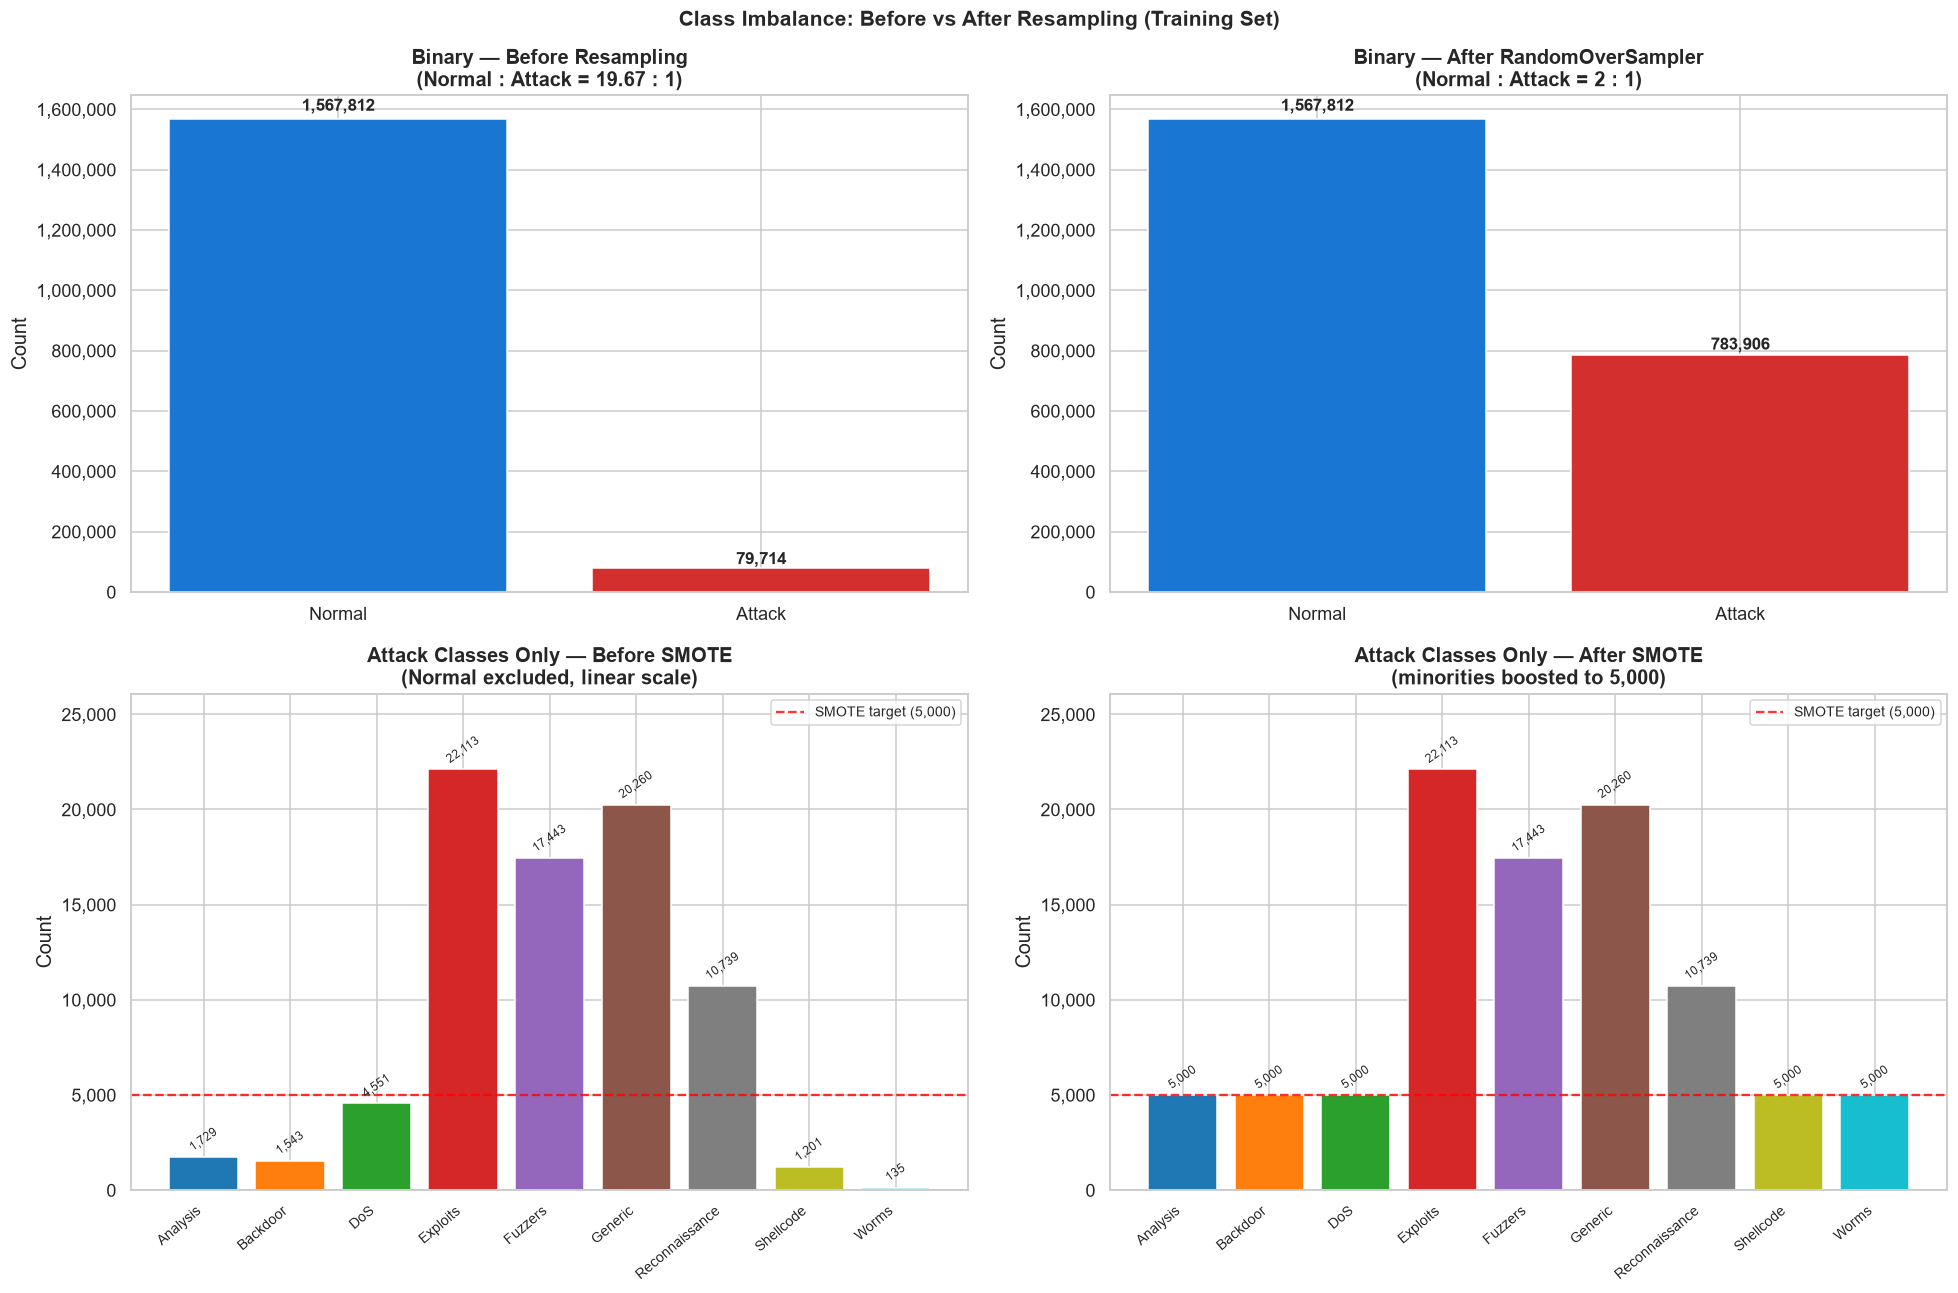

Saved → imbalance_before_after.png

Note: Multiclass row shows ATTACK classes only (Normal=1,567,812 unchanged)
      Normal vs Attack balance is shown in the binary row above.


In [21]:
# ── Imbalance before / after visualisation ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
pal = sns.color_palette('tab10', n_colors=len(le_attack_cat.classes_))

# ── Row 1: Binary (full dataset, Normal included) ─────────────────────────────
ax = axes[0, 0]
vc_b = Counter(y_train_bin)
labels_b = ['Normal', 'Attack']
vals_b   = [vc_b[0], vc_b[1]]
bars = ax.bar(labels_b, vals_b, color=['#1976D2', '#D32F2F'], edgecolor='white')
for b, v in zip(bars, vals_b):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Binary — Before Resampling\n(Normal : Attack = 19.67 : 1)', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[0, 1]
vc_b2 = Counter(y_train_bin_res)
vals_b2 = [vc_b2[0], vc_b2[1]]
bars2 = ax.bar(labels_b, vals_b2, color=['#1976D2', '#D32F2F'], edgecolor='white')
for b, v in zip(bars2, vals_b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Binary — After RandomOverSampler\n(Normal : Attack = 2 : 1)', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Row 2: Multiclass ATTACK CLASSES ONLY (Normal excluded — see binary row) ──
# Excluding Normal makes the SMOTE effect clearly visible on a human-readable scale.
attack_cls_ids = [i for i in sorted(train_mult_counts) if i != majority_class]
attack_names   = [le_attack_cat.classes_[i] for i in attack_cls_ids]

ax = axes[1, 0]
before_vals = [train_mult_counts[i] for i in attack_cls_ids]
bar_colors  = [pal[i % 10] for i in attack_cls_ids]
bars_b = ax.bar(range(len(attack_cls_ids)), before_vals,
                color=bar_colors, edgecolor='white')
for bar, val in zip(bars_b, before_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=35)
ax.axhline(y=5000, color='red', linestyle='--', linewidth=1.5,
           alpha=0.8, label='SMOTE target (5,000)')
ax.set_xticks(range(len(attack_cls_ids)))
ax.set_xticklabels(attack_names, rotation=40, ha='right', fontsize=9)
ax.set_title('Attack Classes Only — Before SMOTE\n(Normal excluded, linear scale)',
             fontweight='bold')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1, 1]
after_vals  = [after_counts[i] for i in attack_cls_ids]
bars_a = ax.bar(range(len(attack_cls_ids)), after_vals,
                color=bar_colors, edgecolor='white')
for bar, val in zip(bars_a, after_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=35)
ax.axhline(y=5000, color='red', linestyle='--', linewidth=1.5,
           alpha=0.8, label='SMOTE target (5,000)')
ax.set_xticks(range(len(attack_cls_ids)))
ax.set_xticklabels(attack_names, rotation=40, ha='right', fontsize=9)
ax.set_title('Attack Classes Only — After SMOTE\n(minorities boosted to 5,000)',
             fontweight='bold')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Match y-axis range between both attack plots for fair comparison
max_val = max(max(before_vals), max(after_vals))
for ax in [axes[1, 0], axes[1, 1]]:
    ax.set_ylim(0, max_val * 1.18)

plt.suptitle('Class Imbalance: Before vs After Resampling (Training Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_PRE, 'imbalance_before_after.png'), bbox_inches='tight')
plt.show()
print('Saved → imbalance_before_after.png')
print()
print('Note: Multiclass row shows ATTACK classes only (Normal=1,567,812 unchanged)')
print('      Normal vs Attack balance is shown in the binary row above.')


## ⚠️ SMOTE / Oversampling — Validity for GNN vs Tabular Models

### The fundamental problem with SMOTE + GNN

SMOTE generates **synthetic feature vectors** by interpolating between real training samples in feature space. This works well for tabular models (RF, XGBoost, MLP) because they operate purely on the feature matrix `X`.

For a **GNN-based edge classifier**, however, every flow record (edge) must belong to a **directed edge `(src_ip → dst_ip)`** in the network graph. Synthetic SMOTE samples have no valid IP addresses — they are mathematical interpolations, not real network flows. Inserting them into the graph would mean:

| Problem | Effect |
|---|---|
| Synthetic flows have no real src/dst IP → no valid graph position | Cannot be placed in the topology |
| Interpolated between `Worms(srcip_A, ...)` and `Worms(srcip_B, ...)` | Creates a phantom IP that never existed |
| GNN aggregates neighbourhood features around each node | Synthetic edges corrupt the neighbourhood statistics of real IPs |
| Attack ratio node features (`src_attack_ratio`) were computed from real flows | SMOTE flows are not counted → inconsistency between edge feats and node feats |

### What literature and practice say

1. **Tabular baselines (Phase 4 — RF, XGBoost, MLP):** SMOTE is standard and effective. Benchmark papers (e.g., Moustafa & Slay 2015, Kasongo 2020) all apply SMOTE on the pre-split training features only. ✅ Keep `X_train_binary_resampled.npy` and `X_train_multiclass_resampled.npy` for these models.

2. **GNN edge classification (Phase 5):** The consensus across GNN-NIDS papers (e.g., Lo et al. 2022 E-GraphSAGE, Pujol-Perich et al. 2022) is to handle imbalance through **class-weighted cross-entropy loss**, NOT SMOTE. The loss weight for each class is:

$$w_c = \frac{N}{K \cdot n_c}$$

where $N$ = total training samples, $K$ = number of classes, $n_c$ = count of class $c$.

3. **DropEdge** (randomly removing edges during GNN training with probability $p=0.1$) combined with class-weighted loss is the standard regularisation approach for imbalanced GNN datasets.

### Action plan for this pipeline

| Phase | Model type | Imbalance strategy |
|---|---|---|
| Phase 4 — Baselines | RF, XGBoost, LightGBM | Use `X_train_binary_resampled.npy` (RandomOverSampler) |
| Phase 4 — MLP | MLP | Use `X_train_binary_resampled.npy` + class weights as backup |
| Phase 5 — GNN | GCN / GAT / SAGE | Use **class-weighted CrossEntropyLoss** on the original (unaugmented) training edges |

> The saved `X_train_*_resampled.npy` arrays are **NOT used for GNN training**. They are produced here so Phase 4 tabular models can be evaluated fairly.


## 2.12 — Save All Outputs

All preprocessing artifacts saved to `outputs/preprocessed/` and `outputs/encoders/`.

```
outputs/
├── preprocessed/
│   ├── X_train.npy                       ← scaled features, 80% split
│   ├── X_val.npy                         ← scaled features, 20% split
│   ├── X_test.npy                        ← scaled features, official test set
│   ├── X_train_binary_resampled.npy      ← after RandomOverSampler (2:1)
│   ├── X_train_multiclass_resampled.npy  ← after SMOTE (minorities→5k)
│   ├── y_binary_{train,val,test}.npy
│   ├── y_binary_train_resampled.npy
│   ├── y_multiclass_{train,val,test}.npy
│   ├── y_multiclass_train_resampled.npy
│   ├── node_features.csv                 ← per-IP GNN node features
│   ├── ip_to_node.json                   ← IP string → node index mapping
│   └── feature_names.json                ← metadata
└── encoders/
    ├── le_attack_cat.pkl
    ├── le_service.pkl
    ├── le_state.pkl
    ├── proto_freq_map.pkl
    └── robust_scaler.pkl
```

In [18]:
print('Saving preprocessed arrays...')

# ── Feature matrices ──────────────────────────────────────────────────────────
np.save(os.path.join(OUT_PRE, 'X_train.npy'),                      X_train_scaled)
np.save(os.path.join(OUT_PRE, 'X_val.npy'),                        X_val_scaled)
np.save(os.path.join(OUT_PRE, 'X_test.npy'),                       X_test_scaled)
np.save(os.path.join(OUT_PRE, 'X_train_binary_resampled.npy'),     X_train_bin_res)
np.save(os.path.join(OUT_PRE, 'X_train_multiclass_resampled.npy'), X_train_mult_res)

# ── Binary targets ────────────────────────────────────────────────────────────
np.save(os.path.join(OUT_PRE, 'y_binary_train.npy'),              y_train_bin)
np.save(os.path.join(OUT_PRE, 'y_binary_train_resampled.npy'),    y_train_bin_res)
np.save(os.path.join(OUT_PRE, 'y_binary_val.npy'),                y_val_bin)
np.save(os.path.join(OUT_PRE, 'y_binary_test.npy'),               y_test_bin)

# ── Multiclass targets ────────────────────────────────────────────────────────
np.save(os.path.join(OUT_PRE, 'y_multiclass_train.npy'),          y_train_mult)
np.save(os.path.join(OUT_PRE, 'y_multiclass_train_resampled.npy'),y_train_mult_res)
np.save(os.path.join(OUT_PRE, 'y_multiclass_val.npy'),            y_val_mult)
np.save(os.path.join(OUT_PRE, 'y_multiclass_test.npy'),           y_test_mult)

# ── Feature metadata ──────────────────────────────────────────────────────────
feat_meta = {
    'feature_names'               : FEATURE_COLS_FINAL,
    'n_features'                  : len(FEATURE_COLS_FINAL),
    'n_classes_binary'            : 2,
    'n_classes_multiclass'        : int(len(le_attack_cat.classes_)),
    'class_names'                 : le_attack_cat.classes_.tolist(),
    'class_map'                   : {int(i): c for i, c in enumerate(le_attack_cat.classes_)},
    'dropped_corr_cols'           : DROP_CORR,
    'dropped_id_cols'             : IP_COLS + TS_COLS,
    'train_size'                  : int(len(X_train_scaled)),
    'val_size'                    : int(len(X_val_scaled)),
    'test_size'                   : int(len(X_test_scaled)),
    'train_binary_resampled_size' : int(len(X_train_bin_res)),
    'train_mult_resampled_size'   : int(len(X_train_mult_res)),
    'binary_strategy'             : 'SMOTE' if USE_SMOTE_BINARY else 'RandomOverSampler',
    'multiclass_strategy'         : 'SMOTE (minorities → 5000)',
    'smote_k_neighbors'           : 3,
    'scaler'                      : 'RobustScaler',
}
with open(os.path.join(OUT_PRE, 'feature_names.json'), 'w') as fh:
    json.dump(feat_meta, fh, indent=2)

print('\nAll files saved:')
total_mb = 0
for fname in sorted(os.listdir(OUT_PRE)):
    fpath = os.path.join(OUT_PRE, fname)
    if os.path.isfile(fpath):
        mb = os.path.getsize(fpath) / 1024**2
        total_mb += mb
        print(f'  {fname:55s}  {mb:6.1f} MB')
print(f'  {"Total":55s}  {total_mb:6.1f} MB')

Saving preprocessed arrays...

All files saved:
  X_test.npy                                                 11.6 MB
  X_train.npy                                               232.5 MB
  X_train_binary_resampled.npy                              331.9 MB
  X_train_multiclass_resampled.npy                          234.8 MB
  X_val.npy                                                  58.1 MB
  feature_names.json                                          0.0 MB
  imbalance_before_after.png                                  0.1 MB
  ip_to_node.json                                             0.0 MB
  node_features.csv                                           0.0 MB
  node_features_meta.json                                     0.0 MB
  y_binary_test.npy                                           0.3 MB
  y_binary_train.npy                                          6.3 MB
  y_binary_train_resampled.npy                                9.0 MB
  y_binary_val.npy                                     

## 2.13 — Phase 2 Summary

In [19]:
n_raw    = sum(s['total'] for s in file_stats)
n_dedup  = len(df)
n_removed= n_raw - n_dedup

print('=' * 65)
print('  PHASE 2 PREPROCESSING — COMPLETE')
print('=' * 65)
print(f'  Raw rows loaded              : {n_raw:>12,}')
print(f'  Duplicate rows removed       : {n_removed:>12,}  ({n_removed/n_raw*100:.2f}%)')
print(f'  Clean rows                   : {n_dedup:>12,}')
print()
print(f'  Features before selection    : {49 - len(TARGET_COLS) - len(IP_COLS) - len(TS_COLS):>12}')
print(f'  High-corr features dropped   : {len(DROP_CORR):>12}')
print(f'  Final feature count          : {len(FEATURE_COLS_FINAL):>12}')
print()
print('  Splits:')
print(f'    Train (80 %)               : {len(X_train_scaled):>12,}  rows')
print(f'    Val   (20 %)               : {len(X_val_scaled):>12,}  rows')
print(f'    Test  (official)           : {len(X_test_scaled):>12,}  rows')
print()
print('  After resampling (train only):')
print(f'    Binary   (2:1 ratio)       : {len(X_train_bin_res):>12,}  rows')
print(f'    Multiclass (SMOTE)         : {len(X_train_mult_res):>12,}  rows')
print()
print('  Node features for GNN:')
print(f'    Unique IPs (nodes)         : {len(node_feat_df):>12,}')
print(f'    Node feature dim           : {len(NODE_FEAT_COLS):>12}')
print()
print('  Outputs:')
print(f'    Arrays   → {OUT_PRE}')
print(f'    Encoders → {OUT_ENC}')
print('=' * 65)
print()
print('  Next step → Phase 3: Graph Construction (03_graph_construction.ipynb)')
print('    Use node_features.csv + ip_to_node.json + X_train.npy')
print('    to build the PyTorch Geometric Data object.')

  PHASE 2 PREPROCESSING — COMPLETE
  Raw rows loaded              :    2,540,047
  Duplicate rows removed       :      480,639  (18.92%)
  Clean rows                   :    2,059,408

  Features before selection    :           43
  High-corr features dropped   :            6
  Final feature count          :           37

  Splits:
    Train (80 %)               :    1,647,526  rows
    Val   (20 %)               :      411,882  rows
    Test  (official)           :       82,332  rows

  After resampling (train only):
    Binary   (2:1 ratio)       :    2,351,718  rows
    Multiclass (SMOTE)         :    1,663,367  rows

  Node features for GNN:
    Unique IPs (nodes)         :           50
    Node feature dim           :           11

  Outputs:
    Arrays   → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\preprocessed
    Encoders → c:\Users\Asus\OneDrive\Desktop\GNN\UNSW-NB15\outputs\encoders

  Next step → Phase 3: Graph Construction (03_graph_construction.ipynb)
    Use node